<a href="https://colab.research.google.com/github/mynameisnitya/Federated-LEarning-for-CVD-Prediction/blob/main/01_MIMIC_Exploration_CVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Drive for Reading dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title
#import zipfile

#zip_path = "/content/drive/MyDrive/MIMIC-III/mimic-iii-clinical-database-1.4.zip"
#extract_path = "/content/drive/MyDrive/MIMIC-III/data"

#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    #zip_ref.extractall(extract_path)

#LOAD CORE TABLES


In [ ]:

import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/MIMIC-III/data/mimic-iii-clinical-database-1.4/"

# Small tables (safe)

patients = pd.read_csv(BASE_PATH + "PATIENTS.csv.gz")
admissions = pd.read_csv(BASE_PATH + "ADMISSIONS.csv.gz")
diagnoses = pd.read_csv(BASE_PATH + "DIAGNOSES_ICD.csv.gz")
d_icd = pd.read_csv(BASE_PATH + "D_ICD_DIAGNOSES.csv.gz")

print("PATIENTS:", patients.shape)
print("ADMISSIONS:", admissions.shape)
print("DIAGNOSES:", diagnoses.shape)
print("D_ICD:", d_icd.shape)

print("Loaded data")


PATIENTS: (46520, 8)
ADMISSIONS: (58976, 19)
DIAGNOSES: (651047, 5)
D_ICD: (14567, 4)
Loaded data


In [ ]:
patients.head()


,ROW_ID,SUBJECT_ID,GENDER,DOB,DOD,DOD_HOSP,DOD_SSN,EXPIRE_FLAG
0,234,249,F,2075-03-13 00:00:00,NaN,NaN,NaN,0
1,235,250,F,2164-12-27 00:00:00,2188-11-22 00:00:00,2188-11-22 00:00:00,NaN,1
2,236,251,M,2090-03-15 00:00:00,NaN,NaN,NaN,0
3,237,252,M,2078-03-06 00:00:00,NaN,NaN,NaN,0
4,238,253,F,2089-11-26 00:00:00,NaN,NaN,NaN,0


In [ ]:
admissions.head()


,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1


In [ ]:
diagnoses.head()

,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
0,1297,109,172335,1.0,40301
1,1298,109,172335,2.0,486
2,1299,109,172335,3.0,58281
3,1300,109,172335,4.0,5855
4,1301,109,172335,5.0,4254


## Check for Missing Values

In [ ]:
print("----NULL VALUES---")
print("Patients: \n",patients.isnull().sum())
print("---------------------------------")
print("Admissions: \n",admissions.isnull().sum())
print("---------------------------------")
print("Diagnoses: \n",diagnoses.isnull().sum())

----NULL VALUES---
Patients: 
 ROW_ID             0
SUBJECT_ID         0
GENDER             0
DOB                0
DOD            30761
DOD_HOSP       36546
DOD_SSN        33142
EXPIRE_FLAG        0
dtype: int64
---------------------------------
Admissions: 
 ROW_ID                      0
SUBJECT_ID                  0
HADM_ID                     0
ADMITTIME                   0
DISCHTIME                   0
DEATHTIME               53122
ADMISSION_TYPE              0
ADMISSION_LOCATION          0
DISCHARGE_LOCATION          0
INSURANCE                   0
LANGUAGE                25332
RELIGION                  458
MARITAL_STATUS          10128
ETHNICITY                   0
EDREGTIME               28099
EDOUTTIME               28099
DIAGNOSIS                  25
HOSPITAL_EXPIRE_FLAG        0
HAS_CHARTEVENTS_DATA        0
dtype: int64
---------------------------------
Diagnoses: 
 ROW_ID         0
SUBJECT_ID     0
HADM_ID        0
SEQ_NUM       47
ICD9_CODE     47
dtype: int64


# Statistics

In [ ]:
print("Unique Patients:",
      patients["SUBJECT_ID"].nunique())

print("Unique Admissions:",
      admissions["HADM_ID"].nunique())

Unique Patients: 46520
Unique Admissions: 58976


## CVD Patients

In [ ]:
diagnoses["ICD9_CODE"] = diagnoses[
    "ICD9_CODE"
].astype(str)

cvd = diagnoses[
    diagnoses["ICD9_CODE"].str.match(
        r'^(39|40|41|42|43|44|45)'
    )
]

print(
    "CVD Patients:",
    cvd["SUBJECT_ID"].nunique()
)

CVD Patients: 32503


# Load Lab Events

In [ ]:
labevents = pd.read_csv(
    BASE_PATH + "LABEVENTS.csv.gz",
    usecols=["SUBJECT_ID","ITEMID","VALUENUM"]
)

print(labevents.shape)

(27854055, 3)


## Load Lab Dictionary

In [ ]:
d_labitems = pd.read_csv(
    BASE_PATH + "D_LABITEMS.csv.gz"
)

print(d_labitems.shape)

(753, 6)


 ## Cholesterol Search

In [ ]:
d_labitems[
    d_labitems["LABEL"].str.contains(
        "cholesterol",
        case=False,
        na=False
    )
][["ITEMID","LABEL"]]

,ITEMID,LABEL
126,51472,Cholesterol Crystals
167,50840,"Cholesterol, Ascites"
230,50903,Cholesterol Ratio (Total/HDL)
231,50904,"Cholesterol, HDL"
232,50905,"Cholesterol, LDL, Calculated"
233,50906,"Cholesterol, LDL, Measured"
234,50907,"Cholesterol, Total"
357,51031,"Cholesterol, Body Fluid"
377,51051,"Cholesterol, Pleural"


## Heart Reate Search

In [ ]:
d_items = pd.read_csv(
    BASE_PATH + "D_ITEMS.csv.gz"
)

print(d_items.shape)
d_items[
    d_items["LABEL"].str.contains(
        "heart rate",
        case=False,
        na=False
    )
][["ITEMID","LABEL"]].head(20)

(12487, 10)


,ITEMID,LABEL
475,211,Heart Rate
1897,3494,Lowest Heart Rate
11498,220045,Heart Rate
11499,220046,Heart rate Alarm - High
11500,220047,Heart Rate Alarm - Low


## Search Blood pressure

In [ ]:
d_items[
    d_items["LABEL"].str.contains(
        "systolic",
        case=False,
        na=False
    )
][["ITEMID","LABEL"]].head(20)


,ITEMID,LABEL
295,6,ABP [Systolic]
320,51,Arterial BP [Systolic]
671,442,Manual BP [Systolic]
682,455,NBP [Systolic]
705,480,Orthostat BP sitting [Systolic]
707,482,OrthostatBP standing [Systolic]
709,484,Orthostatic BP lying [Systolic]
715,492,PAP [Systolic]
1437,666,Systolic Unloading
1748,3313,BP Cuff [Systolic]


In [ ]:
d_items[
    d_items["LABEL"].str.contains(
        "diastolic",
        case=False,
        na=False
    )
][["ITEMID","LABEL"]].head(20)

,ITEMID,LABEL
417,153,Diastolic Unloading
4633,8364,ABP [Diastolic]
4637,8368,Arterial BP [Diastolic]
4709,8440,Manual BP [Diastolic]
4710,8441,NBP [Diastolic]
4713,8444,Orthostat BP sitting [Diastolic]
4714,8445,OrthostatBP standing [Diastolic]
4715,8446,Orthostatic BP lying [Diastolic]
4717,8448,PAP [Diastolic]
4759,8502,BP Cuff [Diastolic]


## Feature Extration

## CVD Label
CVD = Cardiovascular disease

In [ ]:
diagnoses["ICD9_CODE"] = (
    diagnoses["ICD9_CODE"]
    .astype(str)
)

cvd_patients = diagnoses[
    diagnoses["ICD9_CODE"]
    .str.match(r'^(39|40|41|42|43|44|45)')
]

labels = (
    cvd_patients
    .groupby("SUBJECT_ID")
    .size()
    .reset_index(name="CVD")
)

labels["CVD"] = 1

print(labels.shape)
labels.head()

(32503, 2)


,SUBJECT_ID,CVD
0,3,1
1,6,1
2,9,1
3,12,1
4,13,1


# Age and Gender

In [ ]:
patients["DOB"] = pd.to_datetime(
    patients["DOB"],
    errors="coerce"
)

admissions["ADMITTIME"] = pd.to_datetime(
    admissions["ADMITTIME"],
    errors="coerce"
)

demo = admissions.merge(
    patients,
    on="SUBJECT_ID"
)

demo["AGE"] = (
    demo["ADMITTIME"].dt.year
    - demo["DOB"].dt.year
)

demo.loc[demo["AGE"] > 89, "AGE"] = 90

demo = demo[
    ["SUBJECT_ID", "AGE", "GENDER"]
]

demo.head()

,SUBJECT_ID,AGE,GENDER
0,22,65,F
1,23,71,M
2,23,75,M
3,24,39,M
4,25,59,M


# Glucose Extraction

In [ ]:
glucose = labevents[
    labevents["ITEMID"] == 50809
]

glucose = (
    glucose.groupby("SUBJECT_ID")
    ["VALUENUM"]
    .mean()
    .reset_index()
)

glucose.columns = [
    "SUBJECT_ID",
    "GLUCOSE"
]

print(glucose.shape)

(24058, 2)


## Cholestrolo Extraction

In [ ]:
cholesterol = labevents[
    labevents["ITEMID"] == 50907
]

cholesterol = (
    cholesterol.groupby("SUBJECT_ID")
    ["VALUENUM"]
    .mean()
    .reset_index()
)

cholesterol.columns = [
    "SUBJECT_ID",
    "CHOLESTEROL"
]

print(cholesterol.shape)

(10480, 2)


In [ ]:
print(labels.shape)
print(demo.shape)
print(glucose.shape)
print(cholesterol.shape)

(10318, 2)
(58976, 3)
(24058, 2)
(10480, 2)


## Extract Vitals

In [ ]:
vital_ids = [220045, 220179, 220180]

chartevents = pd.read_csv(
    BASE_PATH + "CHARTEVENTS.csv.gz",
    usecols=["SUBJECT_ID", "ITEMID", "VALUENUM"],
    chunksize=1000000
)


vital_chunks = []

for chunk in chartevents:
    filtered = chunk[
        chunk["ITEMID"].isin(vital_ids)
    ]
    vital_chunks.append(filtered)

vitals = pd.concat(vital_chunks)

print(vitals.shape)

(5342598, 3)


## Heart Rate /BP Features Extraction

In [ ]:
vitals = vitals.dropna(subset=["VALUENUM"])

vitals = (
    vitals.groupby(
        ["SUBJECT_ID", "ITEMID"]
    )["VALUENUM"]
    .mean()
    .unstack()
)

vitals = vitals.rename(
    columns={
        220045: "HEART_RATE",
        220179: "SYS_BP",
        220180: "DIA_BP"
    }
)

print(vitals.shape)
vitals.head()

(17717, 3)


ITEMID,HEART_RATE,SYS_BP,DIA_BP
SUBJECT_ID,,,
23,76.694444,107.062500,62.187500
34,55.864865,128.055556,59.888889
36,85.586538,127.950000,71.390000
85,106.276596,111.125000,63.687500
107,74.975904,110.776316,50.697368


## Merge

In [ ]:
final_df = demo.copy()

final_df = final_df.merge(
    glucose,
    on="SUBJECT_ID",
    how="left"
)

final_df = final_df.merge(
    cholesterol,
    on="SUBJECT_ID",
    how="left"
)

final_df = final_df.merge(
    vitals,
    on="SUBJECT_ID",
    how="left"
)

final_df = final_df.merge(
    labels,
    on="SUBJECT_ID",
    how="left"
)

final_df["CVD"] = (
    final_df["CVD"]
    .fillna(0)
)

print(final_df.shape)

(58976, 9)


# Data Processing and cleaning

In [ ]:
print( "-"*50,"Dataset Overview:", "-"*50)
print("Dataset Shape:", final_df.shape)
final_df.head()

-------------------------------------------------- Dataset Overview: --------------------------------------------------
Dataset Shape: (58976, 9)


,SUBJECT_ID,AGE,GENDER,GLUCOSE,CHOLESTEROL,HEART_RATE,SYS_BP,DIA_BP,CVD
0,22,65,F,NaN,NaN,NaN,NaN,NaN,1.0
1,23,71,M,116.666667,NaN,76.694444,107.0625,62.1875,1.0
2,23,75,M,116.666667,NaN,76.694444,107.0625,62.1875,1.0
3,24,39,M,NaN,NaN,NaN,NaN,NaN,1.0
4,25,59,M,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
print( "-"*50,"Dataset Duplicates:", "-"*50)
duplicates = final_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

-------------------------------------------------- Dataset Duplicates: --------------------------------------------------
Duplicate Rows: 6655


In [ ]:
final_df[
    final_df.duplicated(keep=False)
].head(20)

,SUBJECT_ID,AGE,GENDER,GLUCOSE,CHOLESTEROL,HEART_RATE,SYS_BP,DIA_BP,CVD
12,34,90,M,116.000000,163.0,55.864865,128.055556,59.888889,1.0
13,34,90,M,116.000000,163.0,55.864865,128.055556,59.888889,1.0
15,36,70,M,117.767442,NaN,85.586538,127.950000,71.390000,1.0
16,36,70,M,117.767442,NaN,85.586538,127.950000,71.390000,1.0
23,357,63,M,130.826087,NaN,82.606557,105.107735,57.437673,1.0
24,357,63,M,130.826087,NaN,82.606557,105.107735,57.437673,1.0
25,357,64,M,130.826087,NaN,82.606557,105.107735,57.437673,1.0
26,357,64,M,130.826087,NaN,82.606557,105.107735,57.437673,1.0
32,362,86,F,NaN,NaN,NaN,NaN,NaN,1.0
33,362,86,F,NaN,NaN,NaN,NaN,NaN,1.0


In [ ]:
print(final_df["SUBJECT_ID"].nunique())
print(len(final_df))

46520
58976


In [ ]:
final_df = final_df.drop_duplicates()

print(final_df.shape)

(52321, 9)


In [ ]:
print(final_df["SUBJECT_ID"].nunique())
print(len(final_df))

46520
52321


In [ ]:
print( "-"*50,"Dataset Missing Values:", "-"*50)
missing = final_df.isnull().sum()

missing_percent = (
    missing / len(final_df)
) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_table.sort_values(
    by="Percentage",
    ascending=False
)

-------------------------------------------------- Dataset Missing Values: --------------------------------------------------


,Missing Values,Percentage
CHOLESTEROL,38768,74.096443
DIA_BP,31189,59.610864
SYS_BP,31189,59.610864
HEART_RATE,30970,59.192294
GLUCOSE,23476,44.869173
SUBJECT_ID,0,0.000000
GENDER,0,0.000000
AGE,0,0.000000
CVD,0,0.000000


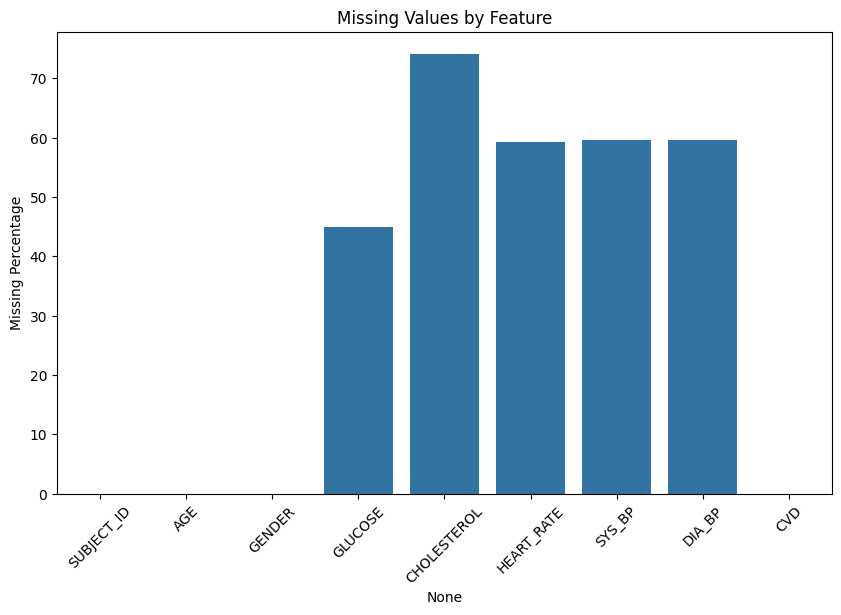

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_table.index,
    y=missing_table["Percentage"]
)

plt.xticks(rotation=45)

plt.ylabel("Missing Percentage")

plt.title(
    "Missing Values by Feature"
)

plt.show()

In [ ]:
final_df

,SUBJECT_ID,AGE,GENDER,GLUCOSE,CHOLESTEROL,HEART_RATE,SYS_BP,DIA_BP,CVD
0,22,65,F,NaN,NaN,NaN,NaN,NaN,1.0
1,23,71,M,116.666667,NaN,76.694444,107.062500,62.187500,1.0
2,23,75,M,116.666667,NaN,76.694444,107.062500,62.187500,1.0
3,24,39,M,NaN,NaN,NaN,NaN,NaN,1.0
4,25,59,M,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...
58971,98800,20,F,99.000000,NaN,89.318182,113.850000,57.250000,0.0
58972,98802,84,F,258.000000,NaN,85.461538,152.538462,80.384615,1.0
58973,98805,42,M,130.500000,NaN,113.979167,142.000000,68.000000,0.0
58974,98813,60,F,124.500000,NaN,94.182927,125.451389,67.118056,1.0


In [ ]:
ml_df = final_df[
[
    "AGE",
    "GENDER",
    "GLUCOSE",
    "CHOLESTEROL",
    "HEART_RATE",
    "SYS_BP",
    "DIA_BP",
    "CVD"
]
]

print(ml_df.shape)

print(
    ml_df.dropna().shape
)

(52321, 8)
(4140, 8)


In [ ]:
final_df["GENDER"] = final_df["GENDER"].map({"M":1,"F":0})

In [ ]:
from sklearn.impute import SimpleImputer

X = final_df[
[
    "AGE",
    "GENDER",
    "GLUCOSE",
    "CHOLESTEROL",
    "HEART_RATE",
    "SYS_BP",
    "DIA_BP"
]
]

y = final_df["CVD"]
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# Check Class Balance

In [ ]:
print(y.value_counts())

print(
    y.value_counts(normalize=True)
)

CVD
1.0    38009
0.0    14312
Name: count, dtype: int64
CVD
1.0    0.726458
0.0    0.273542
Name: proportion, dtype: float64
